# 01 — Photometric Filters

This notebook demonstrates how to download and manage photometric filter transmission curves. `Filters.fetch()` tries the NJM mirror first when it has the requested data, then falls back to the SVO Filter Profile Service.

**Key class:** `Filters`

Downloaded filters are stored in the directory structure expected by MESA's colors module:
```
data/filters/<Facility>/<Instrument>/<Band>.dat
```


In [1]:
from pathlib import Path
from collections import Counter

from sed_tools.api import Filters, SED
import matplotlib.pyplot as plt
import numpy as np
import os


## 1. Querying Available Filters

`Filters.query()` lists locally installed filters and remote facilities. Local entries include an instrument name and `n_filters`; remote entries may be facility-level catalogue entries from SVO or the NJM mirror.


In [2]:
# All available filter entries (local + remote SVO/NJM)
all_filters = Filters.query()
print(f"Total filter entries: {len(all_filters)}")
print("By source:", dict(Counter(f.get("source", "local") for f in all_filters)))

# Locally installed only. Empty/partial directories are ignored.
local_filters = Filters.query(include_remote=False)
print(f"Locally installed: {len(local_filters)}")
for f in local_filters:
    print(f"  {f['facility']}/{f['instrument']}: {f.get('n_filters', '?')} filters")


Total filter sets: 212
Locally installed: 6
  2MASS/2MASS: 3 filters
  GAIA/GAIA: 4 filters
  Generic/Johnson: 7 filters
  Geneva/Geneva: 7 filters
  LSST/LSST: 12 filters
  Roman/WFI: 10 filters


### Filtering by Facility

In [3]:
hst_filters  = Filters.query(facility='HST')
gaia_filters = Filters.query(facility='GAIA')
print(f"HST filter sets:  {len(hst_filters)}")
print(f"Gaia filter sets: {len(gaia_filters)}")

HST filter sets:  1
Gaia filter sets: 2


## 2. Downloading Filters

`Filters.fetch(facility, instrument)` downloads the transmission curves and returns the path to the directory. It uses an existing complete local copy if present, otherwise tries NJM first and falls back to SVO. A download is accepted only when real `.dat` files are present.

Pass positional arguments — facility first, then instrument.


In [ ]:
# Download Johnson broadband filters
johnson_path = Filters.fetch('Generic', 'Johnson')
print(f"Johnson downloaded to: {johnson_path}")

# Download Gaia passbands
gaia_path = Filters.fetch('GAIA', 'GAIA')
print(f"Gaia downloaded to: {gaia_path}")

# Download WISE filters. This is a good smoke test for NJM → SVO fallback.
wise_path = Filters.fetch('WISE', 'WISE')
print(f"WISE downloaded to: {wise_path}")
print("WISE files:", sorted(p.name for p in Path(wise_path).glob("*.dat")))


## 3. Loading and Plotting Transmission Curves

Filter `.dat` files are two-column text: wavelength (Å) and transmission (0–1).

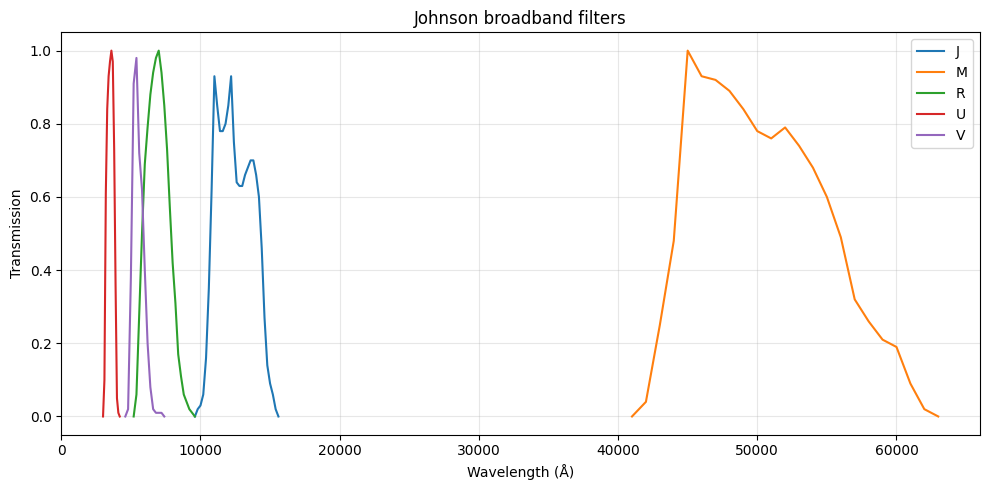

In [5]:
def load_filter(path):
    """Load a two-column filter transmission file."""
    path = Path(path)
    try:
        data = np.loadtxt(path, delimiter=',', skiprows=1)
    except ValueError:
        data = np.loadtxt(path, comments='#')
    return data[:, 0], data[:, 1]  # wavelength (Å), transmission


def plot_filters(filter_dir, title='Filter transmission curves'):
    """Plot all .dat files in a filter directory."""
    filter_dir = Path(filter_dir)
    dat_files = sorted(filter_dir.glob('*.dat'))
    if not dat_files:
        print(f"No .dat files found in {filter_dir}")
        return

    fig, ax = plt.subplots(figsize=(10, 5))
    cmap = plt.get_cmap('tab10')
    for i, path in enumerate(dat_files):
        wl, trans = load_filter(path)
        band = path.stem
        ax.plot(wl, trans, lw=1.5, label=band, color=cmap(i % 10))

    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Transmission')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_filters(johnson_path, title='Johnson broadband filters')


## 4. MESA Filter Reference

MESA identifies filters by the **filename stem** only (no path or extension). For a file at `data/filters/GAIA/GAIA/G.dat`, the MESA reference is just `"G"`.

In [7]:
def list_mesa_filter_names(filter_dir):
    """Print the MESA reference name for each filter in a directory."""
    filter_dir = Path(filter_dir)
    if not filter_dir.is_dir():
        print(f"Directory not found: {filter_dir}")
        return
    for path in sorted(filter_dir.glob('*.dat')):
        print(f"  File: {path.name}  →  MESA reference: '{path.stem}'")


list_mesa_filter_names(gaia_path)


  File: G.dat  →  MESA reference: 'G'
  File: Gbp.dat  →  MESA reference: 'Gbp'
  File: Grp.dat  →  MESA reference: 'Grp'
  File: Grvs.dat  →  MESA reference: 'Grvs'
